# 🛳️ Exploratory Data Analysis – Titanic Dataset

En este notebook vamos a realizar un análisis exploratorio básico del dataset Titanic.

## Campos del dataset
* **PassengerId:** Identificador único de cada pasajero.
* **Survived:** Indica si el pasajero sobrevivió al naufragio.
* **Pclass:** Clase del billete del pasajero. Representa el nivel socioeconómico aproximado.
* **Age:** Edad del pasajero en años.
* **SibSp:** Número de hermanos/as y cónyuges a bordo.
* **Parch:** Número de padres/madres e hijos a bordo.
* **Fare:** Precio pagado por el billete.


## Trabajaremos:
- Carga de datos
- Inspección general
- Estadísticas descriptivas
- Análisis de valores nulos
- Visualizaciones básicas




El objetivo es familiarizarnos con las herramientas principales de `pandas` y `matplotlib`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Configuración básica
plt.rcParams['figure.figsize'] = (8,5)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [3]:
# Cargar el dataset desde una fuente pública
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Información general del dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🔎 Análisis de valores nulos

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 📈 Distribución de la variable objetivo (Survived)

In [7]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

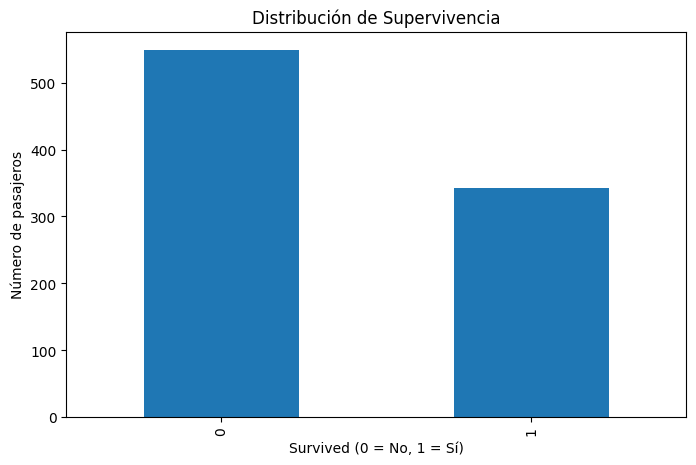

In [8]:
df['Survived'].value_counts().plot(kind='bar')
plt.title('Distribución de Supervivencia')
plt.xlabel('Survived (0 = No, 1 = Sí)')
plt.ylabel('Número de pasajeros')
plt.show()

## 📈 Distribución de la edad

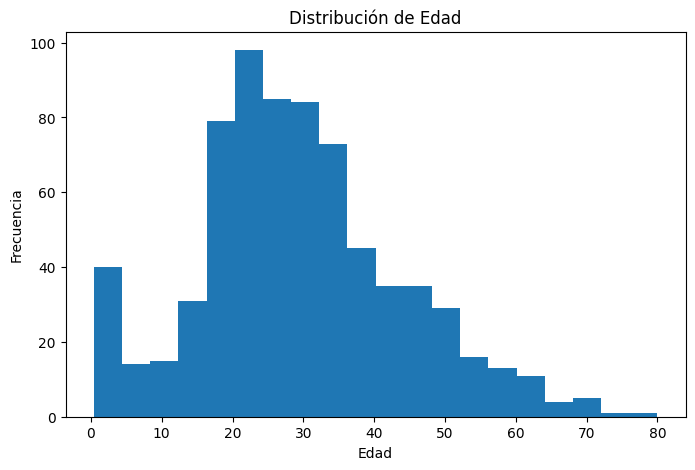

In [9]:
df['Age'].plot(kind='hist', bins=20)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

## 👩‍🦰👨 Supervivencia por sexo

In [10]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

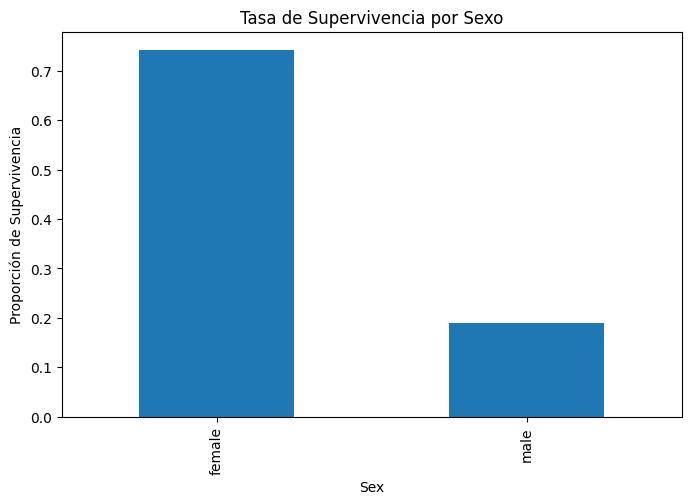

In [11]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Tasa de Supervivencia por Sexo')
plt.ylabel('Proporción de Supervivencia')
plt.show()

## 🔗 Correlación entre variables numéricas

In [12]:
corr = df.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


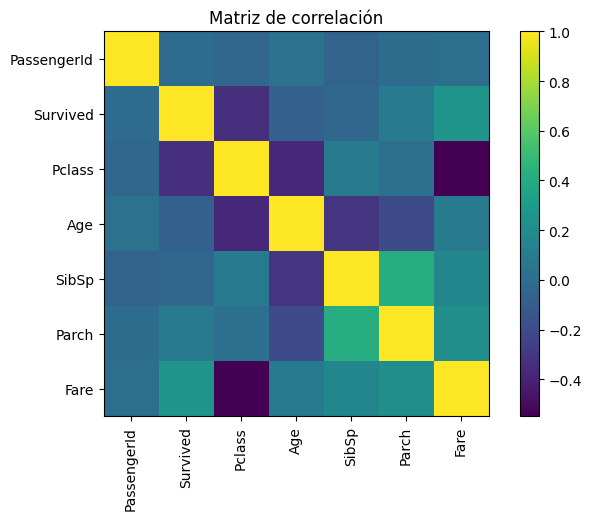

In [13]:
plt.imshow(corr)
plt.title('Matriz de correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

# 🧠 Reflexión final


## Para cada variable, responde:

* ¿Es numérica o categórica? es categorica los mujeres de primera clase y niños tienen mas tasas de supervivencia.
* Si es numérica: ¿es discreta o continua? Es Discreta
* Si es categórica: ¿es nominal u ordinal? Nominal


## Otras preguntas:

1. ¿Qué variables parecen más relacionadas con la supervivencia? Genero, edad y categoria social
2. ¿Qué columnas tienen más valores nulos? tienen mas valores nulos en supervivientes ayores de edad. La columna Age es la que tiene más valores nulos.